In [11]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim
import numpy as np

device = 'cuda'

from sda.mcs import KolmogorovFlow

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=2


KeyboardInterrupt: 

In [20]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "dataset_name": "KolmogorovFlow",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [10, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 500
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [2]:
def compute_estimate(model, k, cond, gt):
    #dNoisy = torch.randn_like(gt).to('cuda')
    with torch.no_grad():

        interm_estimates = []
        
        dNoisy = model.sqrtAlphasCumprod[k] * gt + model.sqrtOneMinusAlphasCumprod[k] * torch.randn_like(gt).to('cuda')

        for i in reversed(range(0, k+1, 1)):


            t = i * torch.ones(dNoisy.shape[0]).to('cuda').long()
            dNoiseCond = torch.concat((cond, dNoisy), dim=1)

            predictedNoiseCond = model.unet(dNoiseCond, t)

            # use model (noise predictor) to predict mean
            modelMean = model.sqrtRecipAlphas[t] * (dNoiseCond - model.betas[t] * predictedNoiseCond / model.sqrtOneMinusAlphasCumprod[t])
            dNoisy = modelMean[:, cond.shape[1]:]
            
            dNoisy = dNoisy + model.sqrtPosteriorVariance[t] * torch.randn_like(dNoisy)

            estimate = (dNoiseCond[:, cond.shape[1]:]  - model.sqrtOneMinusAlphasCumprod[t] * predictedNoiseCond[:, cond.shape[1]:])/model.sqrtAlphasCumprod[t]

            interm_estimates.append(estimate)

        return estimate, interm_estimates

In [3]:
import torch

def run_model(model, x):
    """Wrapper for forward pass."""
    if isinstance(model, DiffusionModel):
        return model(x)
    else:
        return model(x, time=None)

def evaluate_models(models, m_eval, traj_loader, device, rollout_steps=30, with_meta_eval=False):
    """
    Compare:
    - plain model rollouts vs. m_eval rollouts (eval_distances)
    - plain model rollouts vs. model(eval(model)) rollouts (meta_distances)

    Args:
        models (dict): { "name": model } dictionary of models to evaluate
        m_eval (nn.Module): evaluator model
        traj_loader (DataLoader): trajectory loader
        device (torch.device): device to run on
        rollout_steps (int): number of rollout steps

    Returns:
        dict with:
            predictions[name]: list of model rollout tensors
            meta_eval[name]: list of model(eval(model)) rollout tensors
            eval_distances[name]: list of distances vs m_eval
            meta_distances[name]: list of distances vs meta trajectory
    """
    # Put all models in eval mode
    for model in list(models.values()) + [m_eval]:
        model.eval()

    if with_meta_eval :
        meta_eval = {name: [] for name in models}
        meta_distances = {name: [] for name in models}
        meta_preds = {name: [] for name in models}
    
    eval_distances = {name: [] for name in models}

    with torch.no_grad():
        sample = next(iter(traj_loader))

        data = sample["data"].to(device)
        print("Input shape:", data.shape)

        conditioning_frame = data[:, 0]

        # Initialize plain and meta trajectories
        preds = {name: run_model(model, conditioning_frame) for name, model in models.items()}
        predictions = {name: [preds[name]] for name, model in models.items()}
        

        # Store step 0
        for name, model in models.items():    
            pred_eval = run_model(m_eval, conditioning_frame)
            if with_meta_eval:
                meta_preds[name].append(pred_eval)
            eval_distances[name].append(torch.mean((pred_eval - preds[name]) ** 2))

        # Rollout
        for t in range(rollout_steps):
            for name, model in models.items():

                eval_pred_on_model = run_model(m_eval, preds[name])

                if with_meta_eval:
                    model_pred_on_eval = run_model(model, meta_preds[name])
                    meta_preds[name] = eval_pred_on_model
                
                # plain model step
                preds[name] = run_model(model, preds[name])
                predictions[name].append(preds[name])
                
                # distance vs m_eval
                eval_distances[name].append(torch.mean((eval_pred_on_model - preds[name]) ** 2))
                # distance vs meta trajectory
                if with_meta_eval:
                    meta_distances[name].append(torch.mean((model_pred_on_eval - preds[name]) ** 2))

    if with_meta_eval:
        return {
            "predictions": preds,
            "meta_eval": meta_eval,
            "eval_distances": eval_distances,
            "meta_distances": meta_distances,
        }
    return {"predictions": predictions,
            "eval_distances": eval_distances,
            "data": data}


In [15]:
m_eval_1 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_1.load_state_dict(checkpoint)

m_eval_1.to(device)


m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m1 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_196/epoch_581.pth')
m1.load_state_dict(checkpoint)

m2 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/epoch_581.pth')
m2.load_state_dict(checkpoint)

<All keys matched successfully>

In [16]:
results = evaluate_models({"diffusion-2steps-psd": m1, "diffusion-1step-psd": m2}, m_eval_1, traj_loader, device, rollout_steps=10)

Input shape: torch.Size([100, 60, 2, 64, 64])


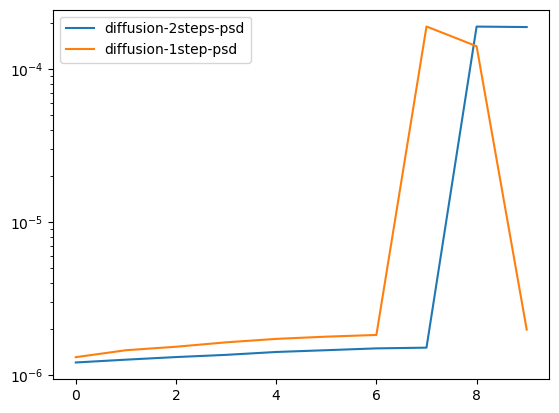

In [17]:
for i, k in enumerate(results["eval_distances"]):
    plt.plot(torch.Tensor(results["eval_distances"][k][:10]), label=k)

plt.yscale('log')

plt.legend()

diffusion-2steps-psd 1.0777699e-06
diffusion-1step-psd 1.0899641e-06


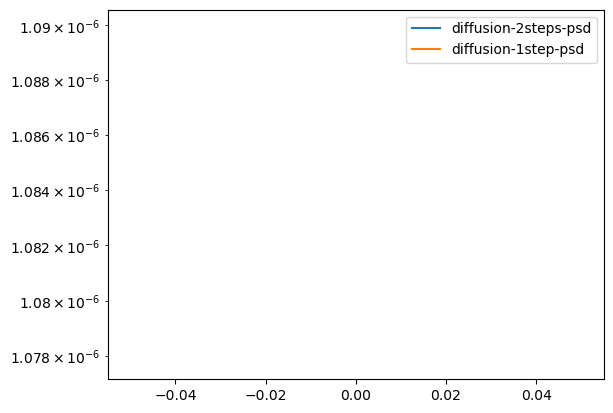

In [19]:
for k in results["eval_distances"].keys():
    plt.plot([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(10)], label=k)
    print(k, np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(10)]))

plt.yscale('log')
plt.legend()

In [8]:
import torch

# ---------- Utilities ----------

def _fft_magnitude(x, take_log=True):
    """Compute magnitude of 2D FFT for tensor (N,C,H,W)."""
    fft = torch.fft.fft2(x)
    mag = torch.abs(fft)
    if take_log:
        mag = torch.log1p(mag)
    return mag


def _radial_average(psd2d):
    """Compute radially averaged power spectrum for (H,W) or (N,C,H,W)."""
    if psd2d.ndim == 4:
        N, C, H, W = psd2d.shape
        cy, cx = H // 2, W // 2
        y, x = torch.meshgrid(torch.arange(H, device=psd2d.device),
                              torch.arange(W, device=psd2d.device),
                              indexing='ij')
        r = torch.sqrt((x - cx)**2 + (y - cy)**2).to(torch.int64)
        nbins = int(r.max()) + 1
        radial_profiles = []
        for n in range(N):
            ch_profiles = []
            for c in range(C):
                psd_flat = psd2d[n, c].flatten()
                r_flat = r.flatten()
                tbin = torch.bincount(r_flat, weights=psd_flat, minlength=nbins)
                nr = torch.bincount(r_flat, minlength=nbins).float()
                radial = tbin / (nr + 1e-8)
                ch_profiles.append(radial)
            radial_profiles.append(torch.stack(ch_profiles))
        return torch.stack(radial_profiles)  # (N,C,K)
    else:
        raise ValueError("Expected (N,C,H,W)")


def _cov_torch(x, eps=1e-6):
    """Covariance along batch dimension."""
    x = x - x.mean(dim=0, keepdim=True)
    N = x.shape[0]
    cov = (x.T @ x) / (N - 1)
    cov += torch.eye(cov.shape[0], device=x.device, dtype=x.dtype) * eps
    return cov


def _sqrtm_symmetric_torch(mat):
    """Matrix square root via eigen-decomposition (symmetric PSD case)."""
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = torch.clamp(eigvals, min=0)
    sqrt_eigvals = torch.sqrt(eigvals)
    return (eigvecs * sqrt_eigvals.unsqueeze(0)) @ eigvecs.T


def frechet_distance_torch(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Compute squared Fréchet distance between two Gaussians.
    """
    diff = mu1 - mu2
    diff_sq = diff.dot(diff)

    # product sqrt: (sigma1 * sigma2)^(1/2)
    cov_prod = sigma1 @ sigma2
    covmean = _sqrtm_symmetric_torch(cov_prod)

    trace_term = torch.trace(sigma1) + torch.trace(sigma2) - 2 * torch.trace(covmean)
    trace_term = torch.clamp(trace_term, min=0)  # avoid tiny negatives
    return diff_sq + trace_term


# ---------- Metrics ----------

def spectral_psd_error(pred, true):
    """
    Mean relative error of radially averaged power spectra.
    pred, true: (N,C,H,W)
    """
    Fp = torch.fft.fftshift(torch.fft.fft2(pred))
    Ft = torch.fft.fftshift(torch.fft.fft2(true))
    psd_pred = torch.abs(Fp) ** 2
    psd_true = torch.abs(Ft) ** 2

    rad_pred = _radial_average(psd_pred)
    rad_true = _radial_average(psd_true)

    rel_err = ((rad_pred - rad_true) ** 2) / (rad_true ** 2 + 1e-8)
    return rel_err.mean()


def spectral_coherence(pred, true):
    """
    Global spectral coherence between predicted and true fields.
    pred, true: (N,C,H,W)
    Returns: scalar in [0,1].
    """
    Fp = torch.fft.fft2(pred)
    Ft = torch.fft.fft2(true)
    num = torch.abs((Fp * Ft.conj()).mean(dim=(-2, -1)))
    denom = torch.sqrt((torch.abs(Fp) ** 2).mean(dim=(-2, -1)) *
                       (torch.abs(Ft) ** 2).mean(dim=(-2, -1)))
    coherence = (num / (denom + 1e-8)).mean()
    return coherence


def fsd_torch_full(real, gen, take_log=True, eps=1e-6, return_sqrt=False):

    N, C, H, W = real.shape
    real_mag = _fft_magnitude(real, take_log)
    gen_mag = _fft_magnitude(gen, take_log)

    # Flatten spatial dims and channels per sample
    Xr = real_mag.view(N, -1)
    Xg = gen_mag.view(N, -1)

    mu_r = Xr.mean(dim=0)
    mu_g = Xg.mean(dim=0)
    cov_r = _cov_torch(Xr, eps)
    cov_g = _cov_torch(Xg, eps)

    fsd_sq = frechet_distance_torch(mu_r, cov_r, mu_g, cov_g)
    return torch.sqrt(fsd_sq) if return_sqrt else fsd_sq


# ---------- Combined evaluator ----------

def spectral_metrics(pred, true):
    """
    Compute spectral correctness metrics between predicted and ground-truth fields.
    Input: (N,C,H,W) tensors
    Output: dict with PSD error, coherence, FSD
    """
    return {
        "psd_error": spectral_psd_error(pred, true),
        "coherence": spectral_coherence(pred, true),
        "fsd": fsd_torch_full(true, pred, return_sqrt=False)
    }


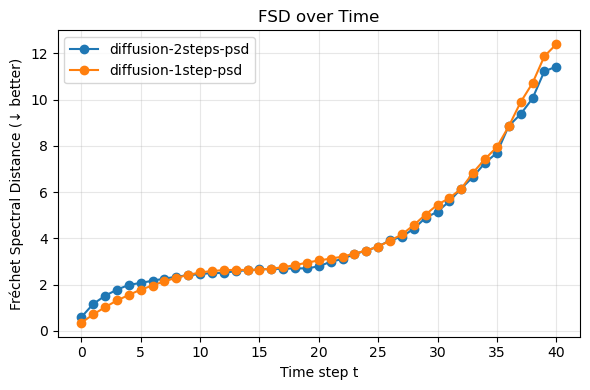

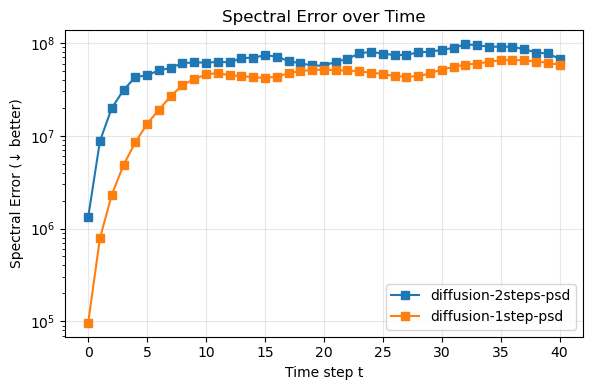

In [9]:
import torch
import matplotlib.pyplot as plt

# Range of time steps to evaluate
T_max = 40

# Store results for all models
metric_over_time = {}

for k in results["eval_distances"].keys():
    fsd_vals = []
    psd_vals = []

    for t in range(T_max + 1):
        pred = results["predictions"][k][t]      # (N,C,H,W)
        gt   = results["data"][:, t + 1]         # (N,C,H,W)
        metrics = spectral_metrics(pred, gt)

        fsd_vals.append(metrics["fsd"].item())
        psd_vals.append(metrics["psd_error"].item())

    metric_over_time[k] = {
        "fsd": torch.tensor(fsd_vals),
        "psd_error": torch.tensor(psd_vals)
    }

# ---- Plot FSD over time ----
plt.figure(figsize=(6, 4))
for k, vals in metric_over_time.items():
    plt.plot(range(T_max + 1), vals["fsd"], marker='o', label=f'{k}')
plt.xlabel("Time step t")
plt.ylabel("Fréchet Spectral Distance (↓ better)")
plt.title("FSD over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot Spectral Error over time ----
plt.figure(figsize=(6, 4))
for k, vals in metric_over_time.items():
    plt.plot(range(T_max + 1), vals["psd_error"], marker='s', label=f'{k}')
plt.xlabel("Time step t")
plt.ylabel("Spectral Error (↓ better)")
plt.title("Spectral Error over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()
